In [1]:
%run DataProcessing.ipynb

C:\Programs\Python39\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, optimizers
from tensorflow.keras.layers import Dense, InputLayer, BatchNormalization, Activation, Dropout, LSTM
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [77]:
def build_model(inputs, outputs, layers, act='relu', verbose=0):
    model = Sequential(name='FCNN')

    model.add(InputLayer(input_shape=(len(inputs[0]))))
    model.add(BatchNormalization())

    for i, n in enumerate(layers):
        #model.add(LSTM(n, input_shape=[layers[i-1]], return_sequences=True))
        model.add(Dense(n))
        model.add(BatchNormalization())
        model.add(Activation(act))

    model.add(Dense(len(outputs[0])))
    
    OPT = optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)
    METS = ['ACC', 'MAE', 'MSE']
    model.compile(optimizer=OPT, loss='MSE', metrics=METS)  # , loss_weights=[1,2])

    if verbose == 1:
        print(model.summary())
    
    return model


def train_model(model, train_in, train_out, EPOCHS=100, BATCH=16, callbacks=None, verbose=0):
    early_stop = EarlyStopping(monitor='val_loss', patience=25, verbose=verbose, mode='min')
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.25, patience=18, verbose=verbose,
                                  min_delta=1e-4, mode='min')
    if callbacks:
        callbacks = [reduce_lr , early_stop]

    fitHistory = model.fit(train_in, train_out, epochs=EPOCHS, batch_size=BATCH, validation_split=0.2, verbose=verbose, 
                           callbacks=callbacks)  #, sample_weight=weights)

    fitHistory_df = pd.DataFrame(fitHistory.history)

    return fitHistory, fitHistory_df

In [81]:
model = build_model(inputs=deltaXY, 
                    outputs=stress,
                    verbose=0,
                    layers=[2048, 1024, 1024, 512, 512, 256], 
                    act='relu') 

fitHistory, fitHistory_df = train_model(model=model, 
                                        train_in=train_in, 
                                        train_out=train_out, 
                                        EPOCHS=50, 
                                        BATCH=16, 
                                        callbacks=True,
                                        verbose=0)

Model: "FCNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization_56 (Ba  (None, 826)               3304      
 tchNormalization)                                               
                                                                 
 dense_50 (Dense)            (None, 2048)              1693696   
                                                                 
 batch_normalization_57 (Ba  (None, 2048)              8192      
 tchNormalization)                                               
                                                                 
 activation_43 (Activation)  (None, 2048)              0         
                                                                 
 dense_51 (Dense)            (None, 1024)              2098176   
                                                                 
 batch_normalization_58 (Ba  (None, 1024)              4096   

In [82]:
pd.DataFrame(fitHistory.history)

,loss,ACC,MAE,MSE,val_loss,val_ACC,val_MAE,val_MSE,lr
0,1.570640,0.012500,0.881793,1.570640,2.037348,0.050000,1.075642,2.037348,0.00100
1,0.407868,0.035227,0.465464,0.407868,1.283099,0.059091,0.851013,1.283099,0.00100
2,0.291815,0.054545,0.385688,0.291815,0.802324,0.054545,0.670889,0.802324,0.00100
3,0.217274,0.042045,0.327417,0.217274,0.725754,0.040909,0.634266,0.725754,0.00100
4,0.172714,0.053409,0.287821,0.172714,0.483864,0.068182,0.461475,0.483864,0.00100
5,0.153350,0.056818,0.267630,0.153350,0.394422,0.054545,0.378764,0.394422,0.00100
6,0.133102,0.065909,0.247946,0.133102,0.384452,0.068182,0.356946,0.384452,0.00100
7,0.119985,0.048864,0.233711,0.119985,0.358576,0.059091,0.333307,0.358576,0.00100
8,0.105456,0.061364,0.219055,0.105456,0.356083,0.077273,0.322029,0.356083,0.00100
9,0.102660,0.060227,0.216074,0.102660,0.355003,0.059091,0.314151,0.355003,0.00100


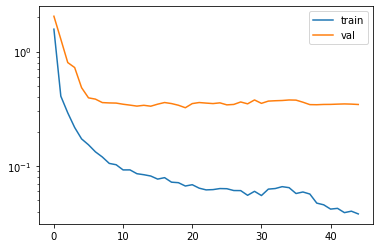

In [85]:
plt.plot(list(fitHistory.history.values())[0], label='train')
plt.plot(list(fitHistory.history.values())[4], label='val')
plt.legend()
plt.yscale('log')

In [83]:
def evaluate(model, fitHistory_df, train_in, train_out, test_in, test_out, BATCH=16):
    trainEv = model.evaluate(train_in, train_out, batch_size=BATCH)
    testEv = model.evaluate(test_in, test_out, batch_size=BATCH)

    ev_df = pd.DataFrame(columns=list(fitHistory_df.columns[:4]))
    ev_df.loc[0] = trainEv
    ev_df.loc[1] = testEv

    return trainEv, testEv, ev_df


def predict_model(model, test_in, test_out):#, test_df):
    pred = model.predict(test_in)

#     clp = [p[0] for p in pred]
#     cdp = [p[1] for p in pred]
#     ldp = [l / d for l, d in zip(clp, cdp)]
#     clt = [t[0] for t in test_out]
#     cdt = [t[1] for t in test_out]
#     ldt = [l / d for l, d in zip(clt, cdt)]
#     p = clp + cdp
#     t = clt + cdt

#     ACC_cl = accuracy(clt, clp)
#     ACC_cd = accuracy(cdt, cdp)
#     ACC = accuracy(t, p)
#     R2_cl = r2_score(clt, clp)
#     R2_cd = r2_score(cdt, cdp)
#     MSE_cl = mean_squared_error(clt, clp)
#     MSE_cd = mean_squared_error(cdt, cdp)
#     MSE = mean_squared_error(t, p)
#     MAE_cl = mean_absolute_error(clt, clp)
#     MAE_cd = mean_absolute_error(cdt, cdp)
#     MAE = mean_absolute_error(t, p)
#     RMSE_cl = math.sqrt(MSE_cl)
#     RMSE_cd = math.sqrt(MSE_cd)
#     RMSE = math.sqrt(MSE)
#     Pmetrics_df = pd.DataFrame({'name': [str(model.name)],
#                                 'ACC_cl': [float(ACC_cl)], 'ACC_cd': [float(ACC_cd)], 'ACC': [float(ACC)],
#                                 'MAE_cl': [float(MAE_cl)], 'MAE_cd': [float(MAE_cd)], 'MAE': [float(MAE)],
#                                 'R2_cl': [float(R2_cl)], 'R2_cd': [float(R2_cd)],
#                                 'MSE_cl': [float(MSE_cl)], 'MSE_cd': [float(MSE_cd)], 'MSE': [float(MSE)],
#                                 'RMSE_cl': [float(RMSE_cl)], 'RMSE_cd': [float(RMSE_cd)], 'RMSE': [float(RMSE)]})

#     output_df = test_df.copy()
#     output_df = output_df.drop(columns=['x', 'y_up', 'y_low'])
#     output_df['LtD'] = ldt
#     output_df['Cl_pred'] = clp
#     output_df['Cd_pred'] = cdp
#     output_df['LtD_pred'] = ldp

    return pred#, Pmetrics_df, output_df

In [84]:
trainEv, testEv, ev_df = evaluate(model=model, 
                                  fitHistory_df=fitHistory_df, 
                                  train_in=train_in, 
                                  train_out=train_out, 
                                  test_in=test_in, 
                                  test_out=test_out, 
                                  BATCH=16)

pred = predict_model(model=model, #, Pmetrics_df, output_df 
                                             test_in=test_in, 
                                             test_out=test_out)

13/13 [==============================] - 0s 5ms/step


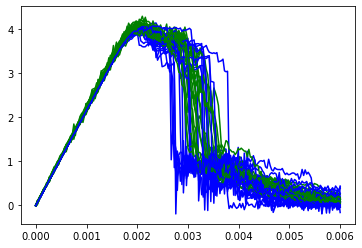

In [86]:
for p, t in zip(pred[:20], test_out[:20]):
    plt.plot(strain, p, color='g')
    plt.plot(strain, t, color='b')

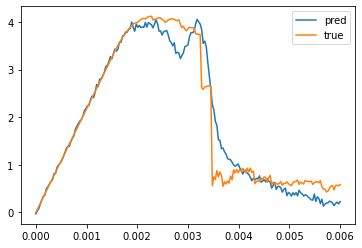

In [66]:
plt.plot(strain, pred[232], label='pred')
plt.plot(strain, test_out[232], label='true')
plt.legend()